# House Price Prediction with Categorical Encoding

In this notebook we will use a real-world housing dataset from Kaggle.

Goals of this notebook:

1. Explore a real dataset
2. Identify numerical and categorical variables
3. Handle missing data
4. Convert categorical variables into numerical form using encoding
5. Train a regression model

## Import Required Libraries

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

## Load the Dataset

In [44]:
df = pd.read_csv("house-prices-advanced-regression-techniques/train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Dataset Overview

The dataset contains many features describing houses, including:

Numerical features:
- LotArea
- OverallQual
- YearBuilt
- GrLivArea

Categorical features:
- Neighborhood
- HouseStyle
- RoofStyle
- SaleCondition

The target variable is:

SalePrice

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## Identify Data Types

In [46]:
numerical_features = df.select_dtypes(include=["int64","float64"]).columns
categorical_features = df.select_dtypes(include=["object"]).columns

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Numerical features: 38
Categorical features: 43


In [47]:
df.isnull().sum().sort_values(ascending=False).head(10)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
dtype: int64

## Why Do We Need Encoding?

Machine learning models require numerical input.

However many variables in the dataset are categorical:

Example:

HouseStyle

- 1Story
- 2Story
- 1.5Fin

These must be converted into numerical representations before training the model.

In [48]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["HouseStyle_encoded"] = le.fit_transform(df["HouseStyle"])

In [49]:
df[["HouseStyle", "HouseStyle_encoded"]].head()

,HouseStyle,HouseStyle_encoded
0,2Story,5
1,1Story,2
2,2Story,5
3,2Story,5
4,2Story,5


### One-Hot Encoding

One-Hot Encoding creates a separate binary column for each category.

Example:

| HouseStyle_1Story | HouseStyle_2Story | HouseStyle_1.5Fin |
|---|---|---|
| 1 | 0 | 0 |
| 0 | 1 | 0 |
| 0 | 0 | 1 |

This avoids introducing artificial ordering.

In [50]:
df_encoded = pd.get_dummies(df, columns=categorical_features)

In [51]:
df_encoded.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,True,False,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,True,False,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,True,False,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,True,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,True,False,False,False,False,True,False


## Preparing Data for Training

In [52]:
X = df_encoded.drop("SalePrice", axis=1)
y = df_encoded["SalePrice"]

## Train/Test Split

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train Linear Regression Model

In [54]:
model = LinearRegression()

model.fit(X_train, y_train)

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
df_encoded.isnull().sum().sort_values(ascending=False).head(10)

LotFrontage      259
GarageYrBlt       81
MasVnrArea         8
MSSubClass         0
GarageCond_Po      0
GarageCond_TA      0
PavedDrive_N       0
PavedDrive_P       0
PavedDrive_Y       0
PoolQC_Ex          0
dtype: int64

## Addressing missing NA values
These are some missing values still remain in the dataset, we need to fix those too. Normally we can modify our previous code and correct this but, in this notebook I have rewrite the code for your reference 

In [55]:
df[categorical_features] = df[categorical_features].fillna("None")

In [56]:
df["LotFrontage"] = df["LotFrontage"].fillna(df["LotFrontage"].median())
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(df["GarageYrBlt"].median())
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)

In [57]:
df_encoded = pd.get_dummies(df, columns=categorical_features)

In [63]:
df_encoded.isnull().sum().sort_values(ascending=False).head(10)

SaleCondition_Partial    0
Id                       0
MiscFeature_Shed         0
MiscFeature_Othr         0
MiscFeature_None         0
MiscFeature_Gar2         0
Fence_None               0
Fence_MnWw               0
Fence_MnPrv              0
Fence_GdWo               0
dtype: int64

In [59]:
X = df_encoded.drop("SalePrice", axis=1)
y = df_encoded["SalePrice"]

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [61]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Model Prediction

In [64]:
predictions = model.predict(X_test)

## Evaluate Model

In [65]:
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 65341.515206268596
R2: 0.44337261621931034


## Visualization of Model Performance

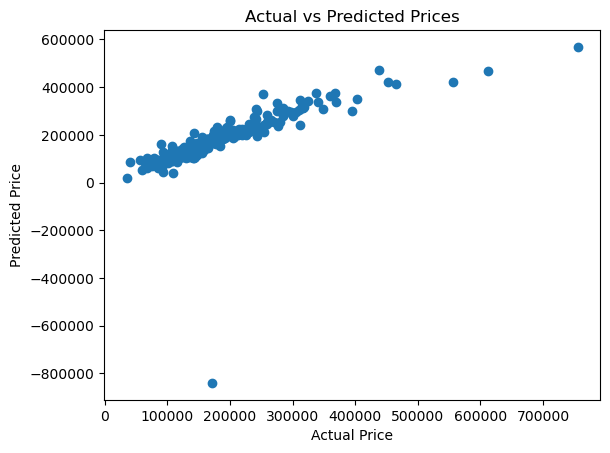

In [66]:
plt.scatter(y_test, predictions)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Prices")

plt.show()

## Save the Model

In [68]:
import joblib

joblib.dump(model, "house_price_model.pkl")

['house_price_model.pkl']

## Load and Use the model

In [69]:
model_load = joblib.load("house_price_model.pkl")

In [73]:
new_house = pd.DataFrame({
    "area": [140],
    "bedrooms": [3],
    "bathrooms": [2],
    "distance_city": [5]
})

predicted_price = model_load.predict(new_house)

print("Predicted price:", predicted_price[0])

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- area
- bathrooms
- bedrooms
- distance_city
Feature names seen at fit time, yet now missing:
- 1stFlrSF
- 2ndFlrSF
- 3SsnPorch
- Alley_Grvl
- Alley_None
- ...


In [74]:
for col in df_encoded.columns:
    print(col)

Id
MSSubClass
LotFrontage
LotArea
OverallQual
OverallCond
YearBuilt
YearRemodAdd
MasVnrArea
BsmtFinSF1
BsmtFinSF2
BsmtUnfSF
TotalBsmtSF
1stFlrSF
2ndFlrSF
LowQualFinSF
GrLivArea
BsmtFullBath
BsmtHalfBath
FullBath
HalfBath
BedroomAbvGr
KitchenAbvGr
TotRmsAbvGrd
Fireplaces
GarageYrBlt
GarageCars
GarageArea
WoodDeckSF
OpenPorchSF
EnclosedPorch
3SsnPorch
ScreenPorch
PoolArea
MiscVal
MoSold
YrSold
SalePrice
HouseStyle_encoded
MSZoning_C (all)
MSZoning_FV
MSZoning_RH
MSZoning_RL
MSZoning_RM
Street_Grvl
Street_Pave
Alley_Grvl
Alley_None
Alley_Pave
LotShape_IR1
LotShape_IR2
LotShape_IR3
LotShape_Reg
LandContour_Bnk
LandContour_HLS
LandContour_Low
LandContour_Lvl
Utilities_AllPub
Utilities_NoSeWa
LotConfig_Corner
LotConfig_CulDSac
LotConfig_FR2
LotConfig_FR3
LotConfig_Inside
LandSlope_Gtl
LandSlope_Mod
LandSlope_Sev
Neighborhood_Blmngtn
Neighborhood_Blueste
Neighborhood_BrDale
Neighborhood_BrkSide
Neighborhood_ClearCr
Neighborhood_CollgCr
Neighborhood_Crawfor
Neighborhood_Edwards
Neighborhood_Gi